In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm

import paths
from utils import get_bin_centers

plt.style.use(paths.styles / 'notebook.mplstyle')

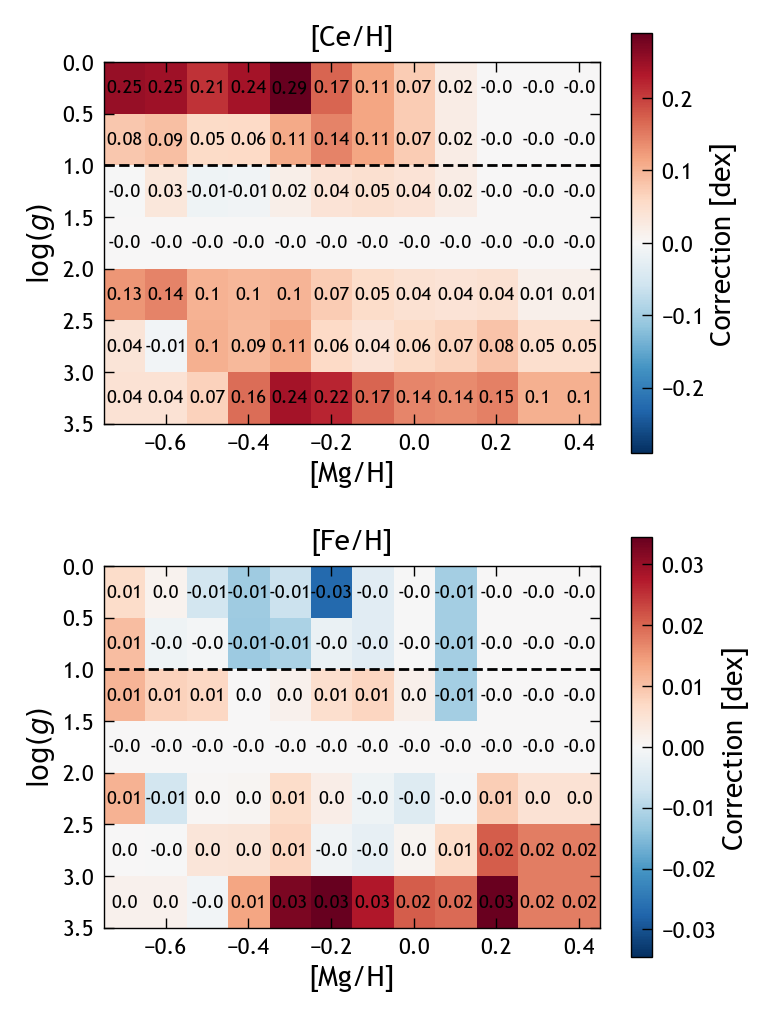

In [15]:
# Load calibration grids
fe_offsets = np.load(paths.data / 'fe_offset_grid.npy')
ce_offsets = np.load(paths.data / 'ce_offset_grid.npy')

# Initialize grid of log(g), [Mg/H] values
MgH_bin_edges = np.round(np.linspace(-0.75, 0.45, 13, endpoint=True), 2)
MgH_bin_centers = get_bin_centers(MgH_bin_edges)
logg_bin_edges = np.linspace(0, 3.5, 8, endpoint=True)
logg_bin_centers = get_bin_centers(logg_bin_edges)
grid = (MgH_bin_centers, logg_bin_centers)
MgH_grid = np.tile(MgH_bin_centers, (len(logg_bin_centers), 1))
logg_grid = np.tile(logg_bin_centers[:,np.newaxis], (len(MgH_bin_centers)))

fig, axs = plt.subplots(2, figsize=(4, 6))
aspect = 0.25
cmap = 'RdBu_r'
img = axs[0].imshow(
    ce_offsets.T, 
    aspect=aspect,
    origin='lower',
    cmap=cmap, 
    norm=CenteredNorm(vcenter=0),
    extent=[MgH_bin_edges[0], MgH_bin_edges[-1], logg_bin_edges[0], logg_bin_edges[-1]]
)
fig.colorbar(img, ax=axs[0], label=r'Correction [dex]')
for i, offset in enumerate(ce_offsets.T.flatten()):
    axs[0].text(
        MgH_grid.flatten()[i], 
        logg_grid.flatten()[i], 
        round(offset, 2), 
        va='center', ha='center',
        size='small'
    )
axs[0].axhline(1, color='k', linestyle='--')
axs[0].set_xlabel('[Mg/H]')
axs[0].set_ylabel(r'$\log(g)$')
axs[0].yaxis.set_inverted(True)
axs[0].set_title('[Ce/H]')

img = axs[1].imshow(
    fe_offsets.T, 
    aspect=aspect,
    origin='lower',
    cmap=cmap, 
    norm=CenteredNorm(vcenter=0),
    extent=[MgH_bin_edges[0], MgH_bin_edges[-1], logg_bin_edges[0], logg_bin_edges[-1]]
)
fig.colorbar(img, ax=axs[1], label=r'Correction [dex]')
for i, offset in enumerate(fe_offsets.T.flatten()):
    axs[1].text(
        MgH_grid.flatten()[i], 
        logg_grid.flatten()[i], 
        round(offset, 2), 
        va='center', ha='center',
        size='small'
    )
axs[1].axhline(1, color='k', linestyle='--')
axs[1].set_xlabel('[Mg/H]')
axs[1].set_ylabel(r'$\log(g)$')
axs[1].yaxis.set_inverted(True)
axs[1].set_title('[Fe/H]')
plt.show()